# Clustering Zona Gempa Bumi di Indonesia

**Mata Kuliah:** Machine Learning — KOM A  
**Kelompok 10**  
- Bobby Rahman Hartanto  
- Davi Ezra Syandana  
- Mahardika Ramadhana  
- Marco Christian  

---

## Latar Belakang
Indonesia merupakan salah satu negara paling aktif secara seismik di dunia, mengalami lebih dari 15.000 gempa per tahun. Satu titik koordinat yang sama dapat mengalami gempa berkali-kali di waktu yang berbeda — pola temporal ini penting untuk menangkap ulangan aktivitas seismik pada zona yang sama.

Proyek ini menggunakan *unsupervised machine learning* (K-Means & DBSCAN) dengan fitur **latitude, longitude, depth, magnitude, dan waktu** untuk menghasilkan zonasi risiko gempa yang lebih representatif.

---
## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from itertools import product

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Library berhasil diimport!')

Library berhasil diimport!


---
## 2. Load dan Eksplorasi Data

In [2]:
df = pd.read_csv('Dataset Gempa Indo.csv')
print(f'Shape dataset awal: {df.shape}')
df.head()

Shape dataset awal: (18289, 22)


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2017-03-19T00:12:32.320Z,1.5742,126.8252,73.93,4.3,mb,NaN,101.0,0.963,0.62,...,2017-06-12T19:46:49.040Z,"106 km NW of Ternate, Indonesia",earthquake,7.5,7.0,0.113,22,reviewed,us,us
1,2017-03-19T15:19:09.030Z,-5.3769,129.7947,191.88,4.1,mb,NaN,95.0,2.988,0.57,...,2017-06-12T19:46:50.040Z,"245 km SSE of Amahai, Indonesia",earthquake,11.0,9.0,0.166,10,reviewed,us,us
2,2017-03-19T17:11:18.810Z,-2.0961,100.5341,78.62,4.2,mb,NaN,150.0,2.458,0.68,...,2017-06-12T19:46:50.040Z,"95 km W of Sungai Penuh, Indonesia",earthquake,7.3,8.8,0.167,10,reviewed,us,us
3,2017-03-20T14:00:41.260Z,2.2182,127.5171,74.50,4.4,mb,NaN,113.0,1.444,0.97,...,2017-06-12T19:46:51.040Z,"77 km NW of Tobelo, Indonesia",earthquake,11.3,9.7,0.098,30,reviewed,us,us
4,2017-03-20T14:45:47.030Z,-10.6530,123.5142,35.00,4.2,mb,NaN,108.0,1.159,0.72,...,2017-06-12T19:46:51.040Z,"54 km S of Kupang, Indonesia",earthquake,7.2,2.0,0.175,9,reviewed,us,us


In [3]:
print('=== Info Dataset ===')
df.info()

=== Info Dataset ===


<class 'pandas.DataFrame'>
RangeIndex: 18289 entries, 0 to 18288
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             18289 non-null  str    
 1   latitude         18289 non-null  float64
 2   longitude        18289 non-null  float64
 3   depth            18289 non-null  float64
 4   mag              18289 non-null  float64
 5   magType          18289 non-null  str    
 6   nst              7623 non-null   float64
 7   gap              18288 non-null  float64
 8   dmin             18288 non-null  float64
 9   rms              18289 non-null  float64
 10  net              18289 non-null  str    
 11  id               18289 non-null  str    
 12  updated          18289 non-null  str    
 13  place            18289 non-null  str    
 14  type             18289 non-null  str    
 15  horizontalError  18289 non-null  float64
 16  depthError       18289 non-null  float64
 17  magError         18289 

In [4]:
print('=== Statistik Deskriptif Fitur Numerik ===')
df[['latitude', 'longitude', 'depth', 'mag']].describe().round(3)

=== Statistik Deskriptif Fitur Numerik ===


,latitude,longitude,depth,mag
count,18289.000,18289.000,18289.000,18289.000
mean,-2.539,122.653,92.606,4.484
std,4.676,10.624,113.494,0.372
min,-11.000,95.017,0.000,3.000
25%,-6.916,119.888,13.150,4.200
50%,-2.819,126.469,51.231,4.400
75%,1.665,128.657,127.513,4.600
max,6.000,140.998,652.530,7.600


In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[lambda x: x['Missing Count'] > 0]

=== Missing Values ===


,Missing Count,Missing %
nst,10666,58.32
gap,1,0.01
dmin,1,0.01


---
## 3. Preprocessing & Rekayasa Fitur

Fitur yang digunakan (5 fitur, tanpa unix_time):

| Fitur | Penjelasan |
|---|---|
| `latitude` | Posisi lintang |
| `longitude` | Posisi bujur |
| `depth` | Kedalaman gempa (km) |
| `mag` | Magnitudo gempa |
| `depth_cat` | Kategori kedalaman: 0=dangkal (<70km), 1=menengah (70–300km), 2=dalam (>300km) |

**Catatan DBSCAN:** dijalankan terpisah per lapisan kedalaman menggunakan jarak Haversine pada koordinat geografis.

In [6]:
# 3.1 Parse kolom waktu
df['time'] = pd.to_datetime(df['time'], utc=True)

print('Rentang waktu dataset:')
print(f'  Mulai : {df["time"].min()}')
print(f'  Akhir : {df["time"].max()}')
print(f'  Durasi: {(df["time"].max() - df["time"].min()).days} hari')

Rentang waktu dataset:


  Mulai : 2017-03-19 00:12:32.320000+00:00
  Akhir : 2026-03-23 11:25:02.168000+00:00
  Durasi: 3291 hari


In [7]:
# 3.2 Rekayasa fitur kedalaman
# Gempa Indonesia punya 3 zona kedalaman yang berbeda secara geologis:
# Dangkal (<70km): risiko permukaan tinggi
# Menengah (70-300km): zona transisi lempeng
# Dalam (>300km): subduksi dalam

def categorize_depth(d):
    if d < 70:    return 0  # dangkal
    elif d < 300: return 1  # menengah
    else:         return 2  # dalam

df['depth_cat'] = df['depth'].apply(categorize_depth)

print('Distribusi kategori kedalaman:')
counts = df['depth_cat'].value_counts().sort_index()
labels_map = {0: 'Dangkal (<70km)', 1: 'Menengah (70-300km)', 2: 'Dalam (>300km)'}
for k, v in counts.items():
    print(f'  {labels_map[k]}: {v:,} ({v/len(df)*100:.1f}%)')

Distribusi kategori kedalaman:
  Dangkal (<70km): 10,897 (59.6%)
  Menengah (70-300km): 6,317 (34.5%)
  Dalam (>300km): 1,075 (5.9%)


In [8]:
# 3.3 Seleksi fitur & drop null
all_features = ['latitude', 'longitude', 'depth', 'mag', 'depth_cat']

df_clean = df[all_features + ['time']].copy()

before = len(df_clean)
df_clean.dropna(subset=all_features, inplace=True)
after  = len(df_clean)
print(f'Baris sebelum drop NA : {before:,}')
print(f'Baris setelah drop NA : {after:,}')
print(f'Dihapus               : {before - after}')

Baris sebelum drop NA : 18,289
Baris setelah drop NA : 18,289
Dihapus               : 0


In [9]:
# 3.4 Filter wilayah Indonesia
df_clean = df_clean[
    (df_clean['latitude'] >= -11) & (df_clean['latitude'] <= 6) &
    (df_clean['longitude'] >= 95)  & (df_clean['longitude'] <= 141)
].copy()
df_clean.reset_index(drop=True, inplace=True)
print(f'Data setelah filter wilayah Indonesia: {len(df_clean):,} baris')

Data setelah filter wilayah Indonesia: 18,289 baris


In [10]:
# 3.5 Standardisasi
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[all_features])

print('Fitur yang digunakan untuk clustering:')
for i, f in enumerate(all_features):
    print(f'  [{i}] {f}')

Fitur yang digunakan untuk clustering:
  [0] latitude
  [1] longitude
  [2] depth
  [3] mag
  [4] depth_cat


---
## 4. Visualisasi Data Awal

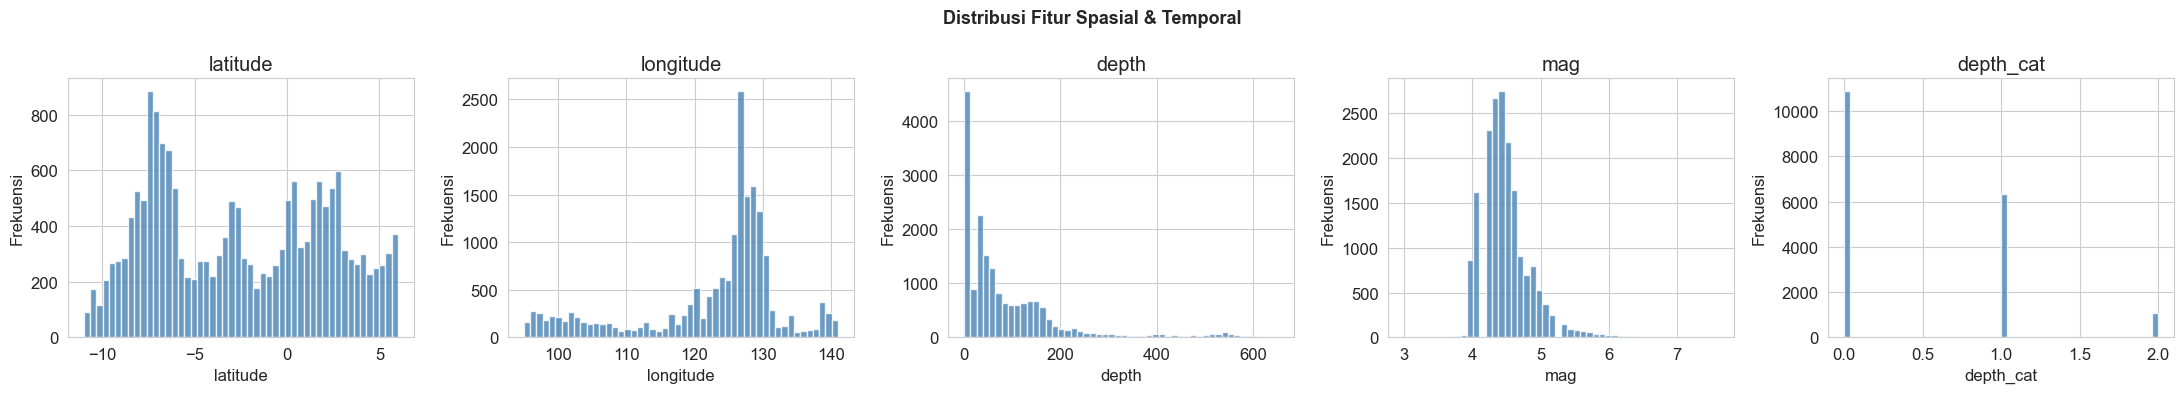

In [11]:
# Distribusi fitur
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, col in enumerate(all_features):
    axes[i].hist(df_clean[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
plt.suptitle('Distribusi Fitur Spasial & Temporal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

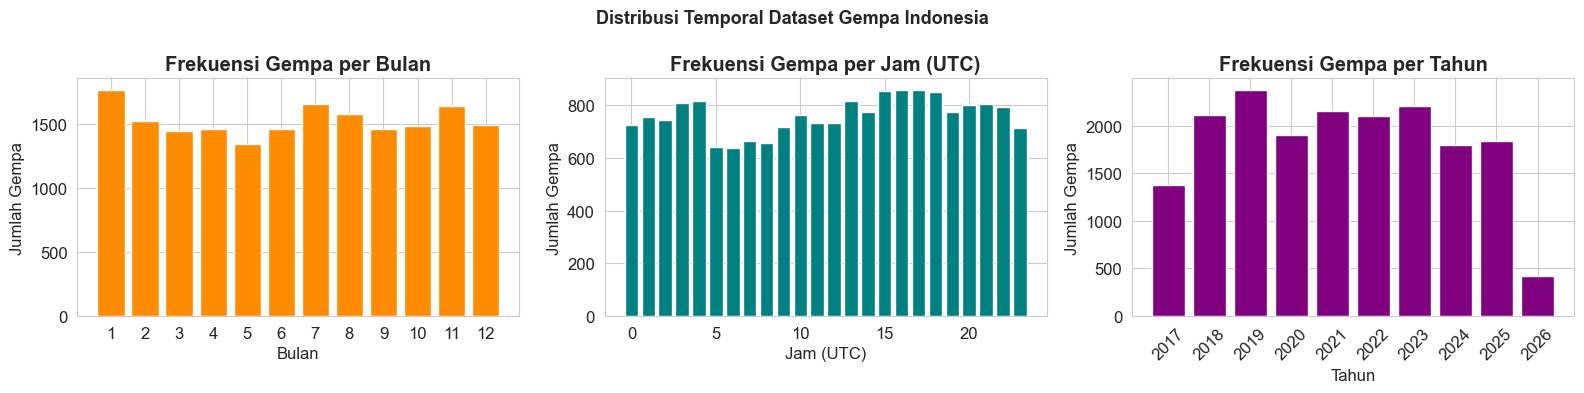

In [12]:
# Distribusi temporal
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_clean['month_parsed'] = df_clean['time'].dt.month
df_clean['hour_parsed']  = df_clean['time'].dt.hour
df_clean['year_parsed']  = df_clean['time'].dt.year

axes[0].bar(range(1,13),
            [df_clean[df_clean['month_parsed']==m].shape[0] for m in range(1,13)],
            color='darkorange', edgecolor='white')
axes[0].set_title('Frekuensi Gempa per Bulan', fontweight='bold')
axes[0].set_xlabel('Bulan'); axes[0].set_ylabel('Jumlah Gempa')
axes[0].set_xticks(range(1,13))

axes[1].bar(range(0,24),
            [df_clean[df_clean['hour_parsed']==h].shape[0] for h in range(0,24)],
            color='teal', edgecolor='white')
axes[1].set_title('Frekuensi Gempa per Jam (UTC)', fontweight='bold')
axes[1].set_xlabel('Jam (UTC)'); axes[1].set_ylabel('Jumlah Gempa')

year_counts = df_clean['year_parsed'].value_counts().sort_index()
axes[2].bar(year_counts.index.astype(str), year_counts.values, color='purple', edgecolor='white')
axes[2].set_title('Frekuensi Gempa per Tahun', fontweight='bold')
axes[2].set_xlabel('Tahun'); axes[2].set_ylabel('Jumlah Gempa')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Distribusi Temporal Dataset Gempa Indonesia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Contoh: titik koordinat yang muncul berkali-kali di waktu berbeda
df_clean['latlon_round'] = (
    df_clean['latitude'].round(1).astype(str) + ',' +
    df_clean['longitude'].round(1).astype(str)
)
repeat_locations = df_clean['latlon_round'].value_counts().head(10)
print('Top 10 lokasi (lat,lon dibulatkan 1 desimal) dengan frekuensi tertinggi:')
print(repeat_locations.to_string())

Top 10 lokasi (lat,lon dibulatkan 1 desimal) dengan frekuensi tertinggi:
latlon_round
1.6,126.5     31
-7.4,128.5    30
-6.6,129.8    30
1.7,126.5     29
2.8,127.0     29
-7.4,128.6    27
2.7,127.0     27
-7.4,128.7    24
1.5,126.4     24
-8.6,118.3    22


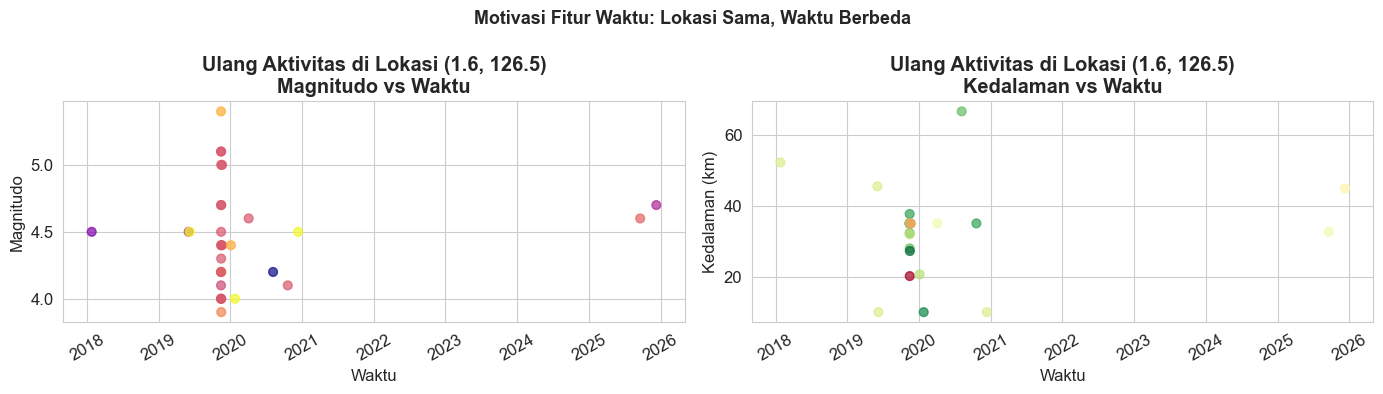

Jumlah kejadian di lokasi ini: 31


In [14]:
# Visualisasi ulang aktivitas di 1 lokasi paling aktif — bukti pentingnya fitur waktu
top_loc = repeat_locations.index[0]
lat_r, lon_r = map(float, top_loc.split(','))

df_hotspot = df_clean[
    (df_clean['latitude'].round(1) == lat_r) &
    (df_clean['longitude'].round(1) == lon_r)
].sort_values('time')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df_hotspot['time'], df_hotspot['mag'],
                c=df_hotspot['depth'], cmap='plasma_r', s=40, alpha=0.7)
axes[0].set_title(f'Ulang Aktivitas di Lokasi ({lat_r}, {lon_r})\nMagnitudo vs Waktu',
                  fontweight='bold')
axes[0].set_xlabel('Waktu'); axes[0].set_ylabel('Magnitudo')
axes[0].tick_params(axis='x', rotation=30)

axes[1].scatter(df_hotspot['time'], df_hotspot['depth'],
                c=df_hotspot['mag'], cmap='RdYlGn_r', s=40, alpha=0.7)
axes[1].set_title(f'Ulang Aktivitas di Lokasi ({lat_r}, {lon_r})\nKedalaman vs Waktu',
                  fontweight='bold')
axes[1].set_xlabel('Waktu'); axes[1].set_ylabel('Kedalaman (km)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Motivasi Fitur Waktu: Lokasi Sama, Waktu Berbeda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Jumlah kejadian di lokasi ini: {len(df_hotspot)}')

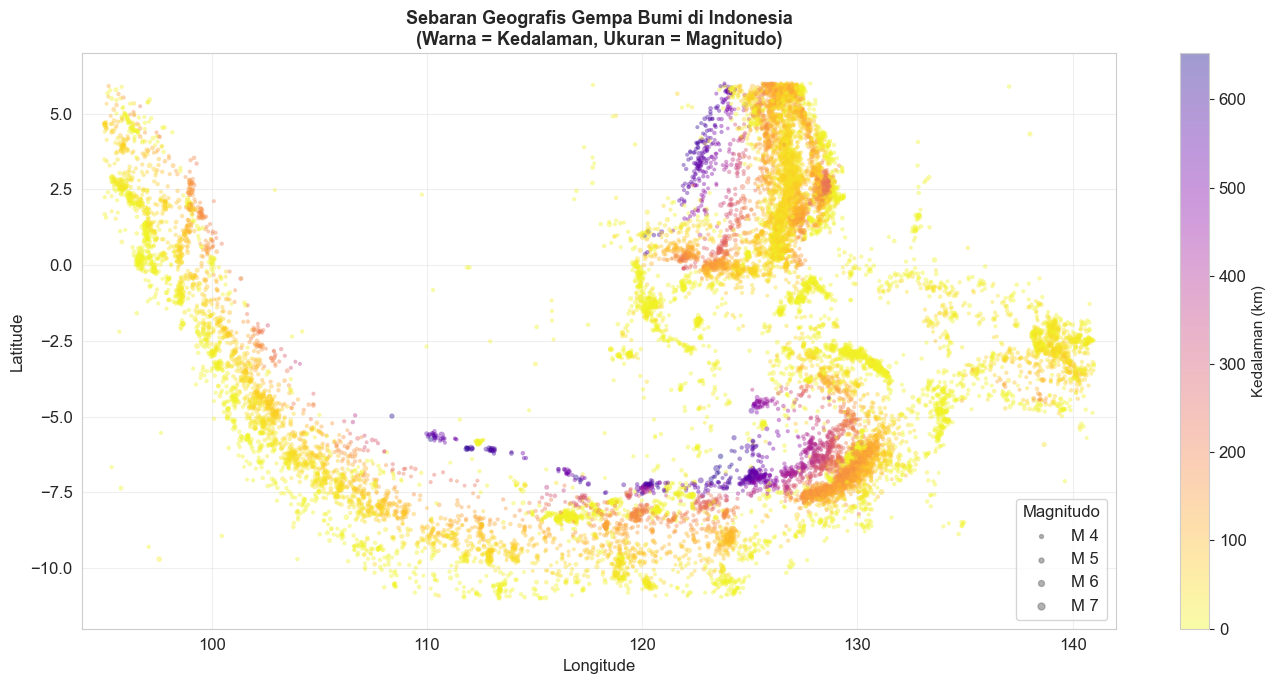

In [15]:
# Sebaran geografis
fig, ax = plt.subplots(figsize=(14, 7))
sc = ax.scatter(
    df_clean['longitude'], df_clean['latitude'],
    c=df_clean['depth'], cmap='plasma_r',
    s=df_clean['mag'] ** 2 * 0.5,
    alpha=0.4, edgecolors='none'
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Kedalaman (km)', fontsize=11)
for mag in [4, 5, 6, 7]:
    ax.scatter([], [], s=mag**2*0.5, c='gray', alpha=0.6, label=f'M {mag}')
ax.legend(title='Magnitudo', loc='lower right')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Sebaran Geografis Gempa Bumi di Indonesia\n(Warna = Kedalaman, Ukuran = Magnitudo)',
             fontsize=13, fontweight='bold')
ax.set_xlim(94, 142); ax.set_ylim(-12, 7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

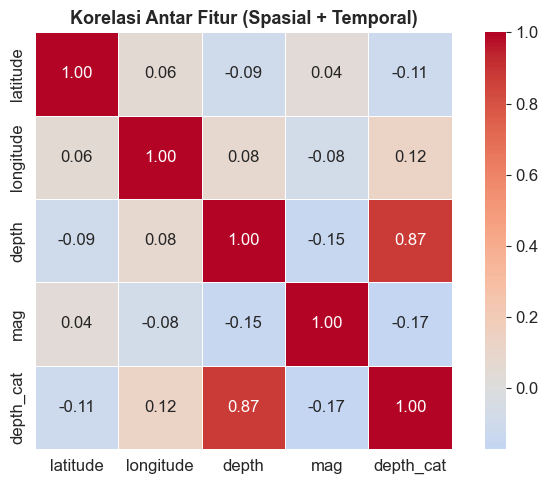

In [16]:
# Correlation heatmap semua fitur
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_clean[all_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Korelasi Antar Fitur (Spasial + Temporal)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. K-Means Clustering

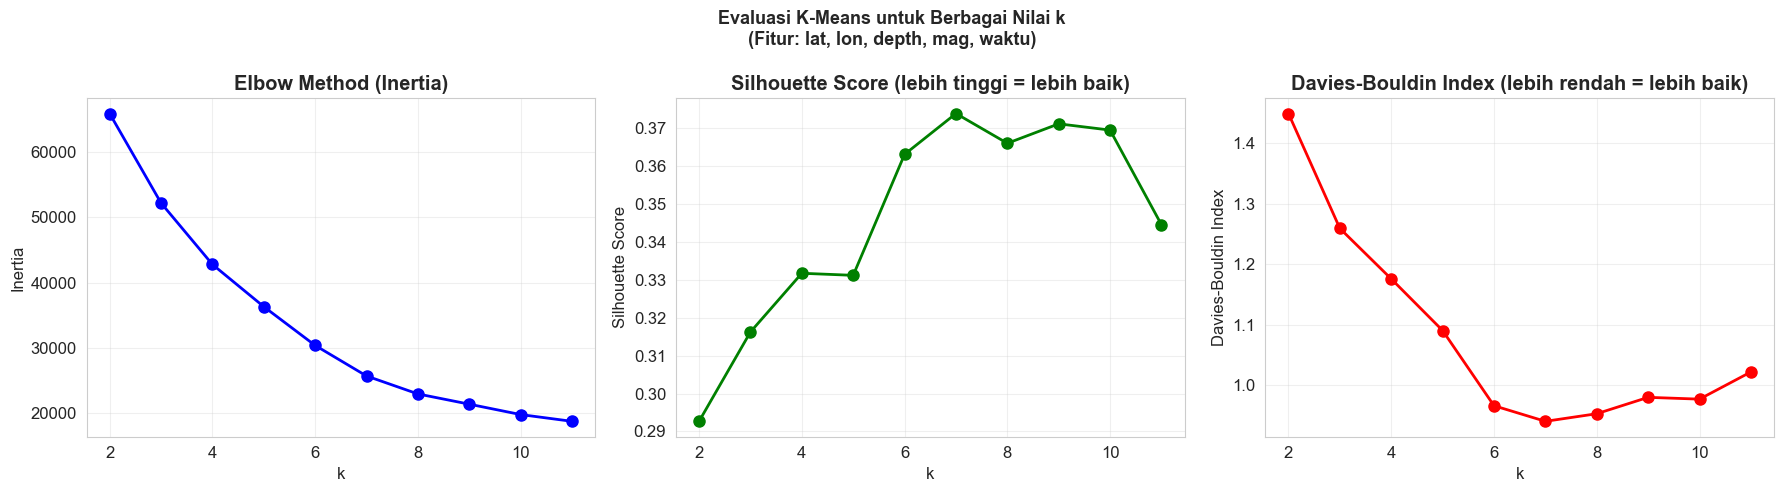

 k    Inertia  Silhouette  Davies-Bouldin
 2 65896.3238      0.2927          1.4493
 3 52186.8857      0.3163          1.2594
 4 42770.7508      0.3318          1.1759
 5 36298.7961      0.3312          1.0904
 6 30356.7508      0.3632          0.9661
 7 25675.2308      0.3739          0.9403
 8 22922.2579      0.3661          0.9529
 9 21352.0066      0.3712          0.9800
10 19760.7970      0.3696          0.9770
11 18724.1698      0.3446          1.0220


In [17]:
# 5.1 Elbow Method + evaluasi untuk menentukan k optimal
inertia_list    = []
silhouette_list = []
db_list         = []
k_range         = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))
    db_list.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(k_range), inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouette_list, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (lebih tinggi = lebih baik)', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(k_range), db_list, 'ro-', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Index (lebih rendah = lebih baik)', fontweight='bold')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Evaluasi K-Means untuk Berbagai Nilai k\n(Fitur: lat, lon, depth, mag, waktu)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

eval_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertia_list,
    'Silhouette': silhouette_list,
    'Davies-Bouldin': db_list
})
print(eval_df.round(4).to_string(index=False))

In [18]:
# 5.2 K-Means final dengan k optimal
best_k = int(eval_df.loc[eval_df['Silhouette'].idxmax(), 'k'])
print(f'k optimal (Silhouette tertinggi): k = {best_k}')

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, df_clean['cluster_kmeans'])
db_km  = davies_bouldin_score(X_scaled, df_clean['cluster_kmeans'])
print(f'Silhouette Score K-Means (k={best_k}): {sil_km:.4f}')
print(f'Davies-Bouldin Index K-Means (k={best_k}): {db_km:.4f}')

k optimal (Silhouette tertinggi): k = 7


Silhouette Score K-Means (k=7): 0.3739
Davies-Bouldin Index K-Means (k=7): 0.9403


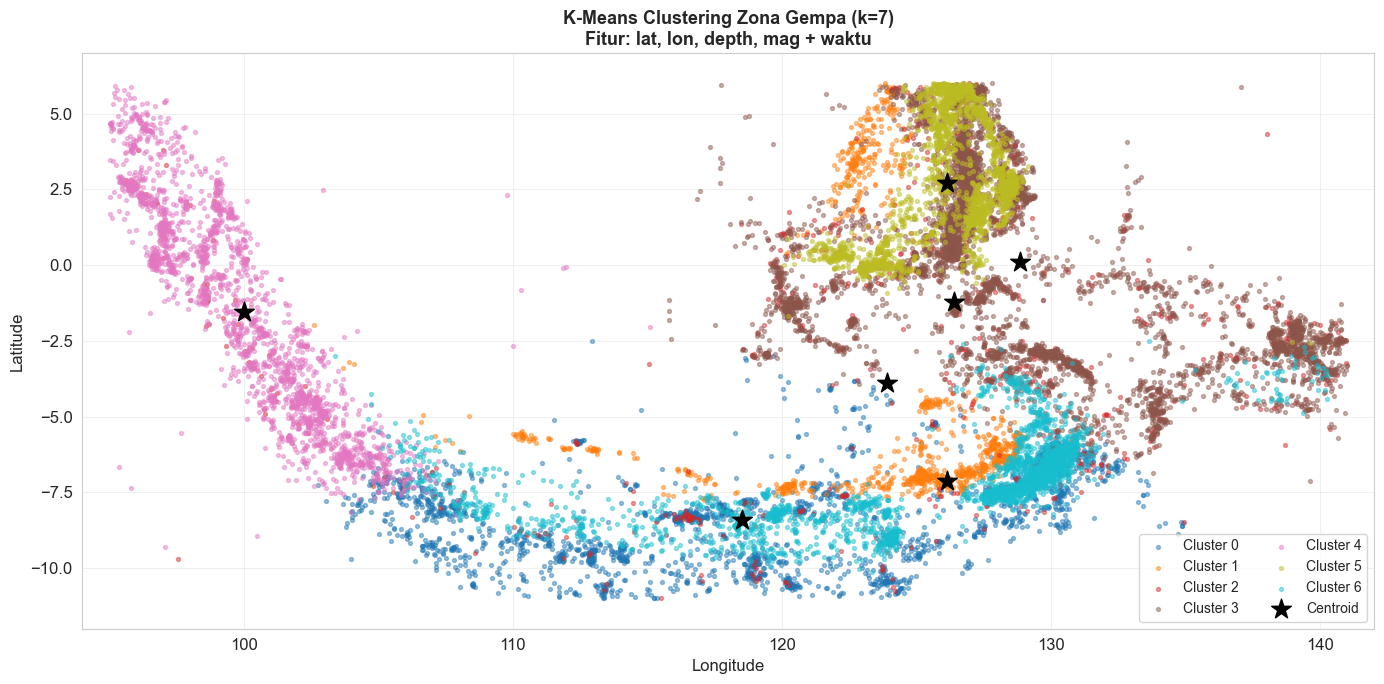

In [19]:
# 5.3 Peta hasil K-Means
colors_km = plt.cm.tab10(np.linspace(0, 1, best_k))
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(14, 7))
for c in range(best_k):
    s = df_clean[df_clean['cluster_kmeans'] == c]
    ax.scatter(s['longitude'], s['latitude'],
               s=8, alpha=0.45, color=colors_km[c], label=f'Cluster {c}')
ax.scatter(centers_orig[:, 1], centers_orig[:, 0],
           c='black', s=220, marker='*', zorder=5, label='Centroid')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'K-Means Clustering Zona Gempa (k={best_k})\nFitur: lat, lon, depth, mag + waktu',
             fontsize=13, fontweight='bold')
ax.set_xlim(94, 142); ax.set_ylim(-12, 7)
ax.legend(loc='lower right', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# 5.4 Profil temporal cluster K-Means
profile_km = df_clean.groupby('cluster_kmeans').agg(
    latitude=('latitude', 'mean'),
    longitude=('longitude', 'mean'),
    depth=('depth', 'mean'),
    mag=('mag', 'mean'),
    waktu_awal=('time', 'min'),
    waktu_akhir=('time', 'max'),
    jumlah=('mag', 'count')
).round(3)
print('=== Profil Cluster K-Means (dengan info temporal) ===')
print(profile_km.to_string())

=== Profil Cluster K-Means (dengan info temporal) ===
                latitude  longitude    depth    mag                       waktu_awal                      waktu_akhir  jumlah
cluster_kmeans                                                                                                               
0                 -8.415    118.483   24.018  4.444 2017-03-20 14:45:47.030000+00:00 2026-03-20 11:20:33.850000+00:00    2298
1                 -3.905    123.905  462.330  4.366 2017-03-23 05:51:21.360000+00:00 2026-03-12 12:05:21.536000+00:00    1073
2                 -1.226    126.385   38.270  5.285 2017-03-21 23:10:25.150000+00:00 2026-03-16 11:53:25.233000+00:00    1534
3                  0.103    128.831   30.154  4.394 2017-03-21 13:10:45.450000+00:00 2026-03-21 19:53:58.896000+00:00    5424
4                 -1.556    100.005   48.188  4.540 2017-03-19 17:11:18.810000+00:00 2026-03-22 03:51:48.953000+00:00    2243
5                  2.706    126.123  133.410  4.399 2017-03-19 0

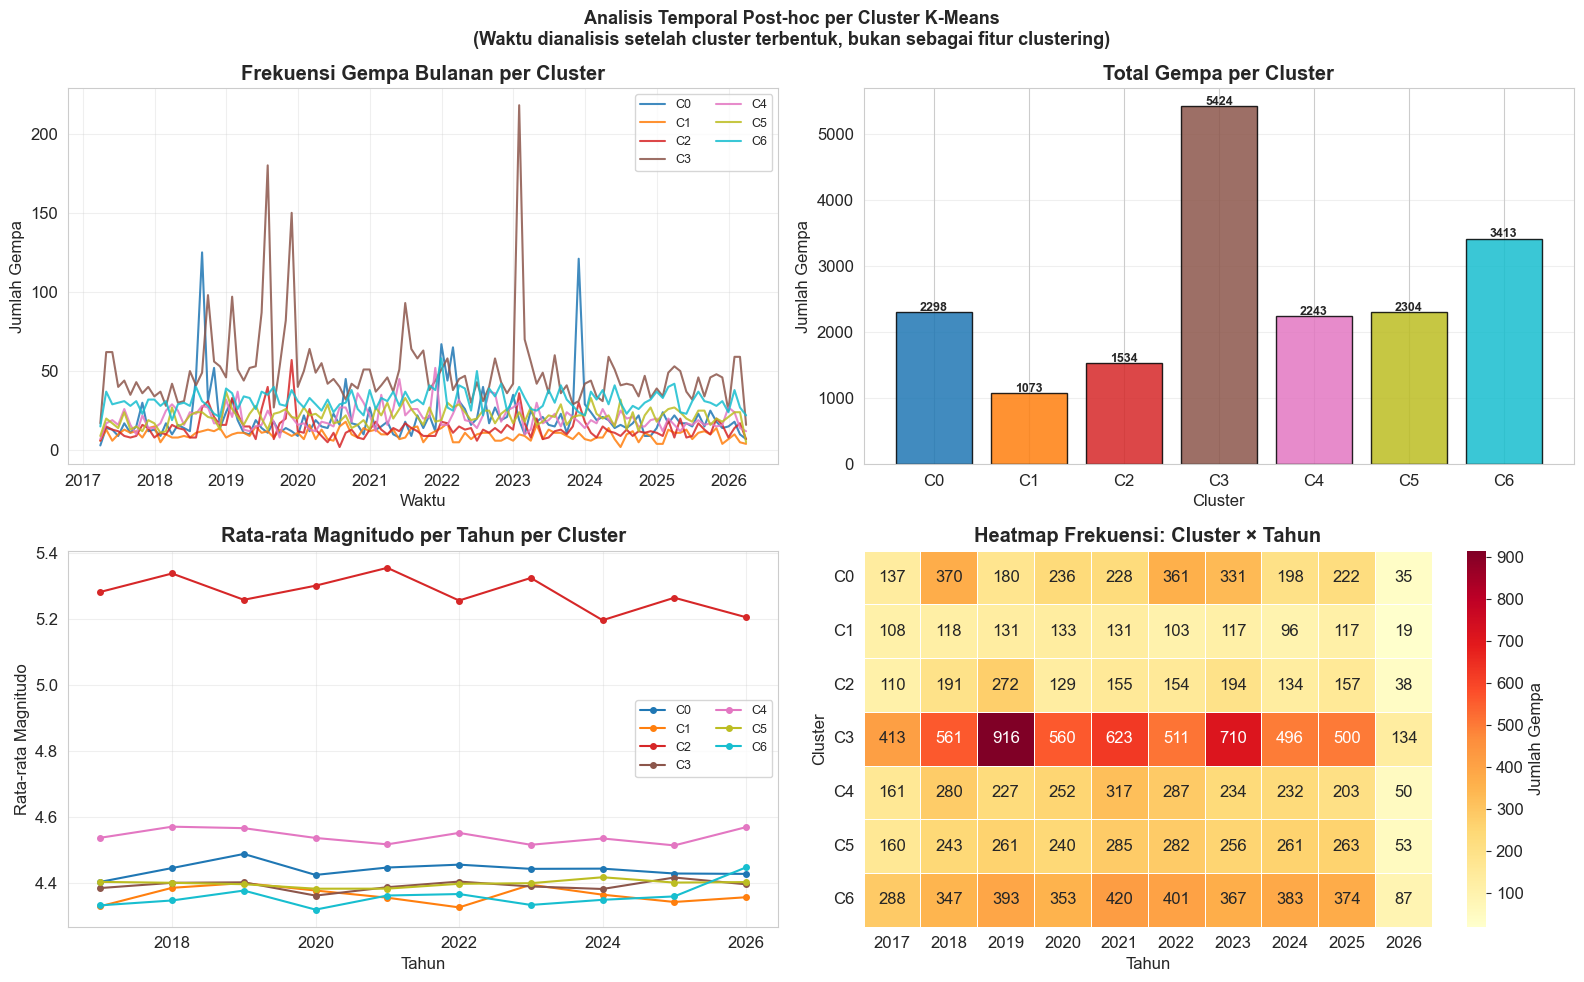

In [21]:
# 5.5 Analisis Temporal Post-hoc per Cluster K-Means
# Meski waktu tidak digunakan sebagai fitur clustering,
# analisis temporal dilakukan setelah cluster terbentuk
# untuk memahami pola aktivitas seismik setiap zona dari waktu ke waktu.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) Aktivitas bulanan per cluster
ax1 = axes[0, 0]
for c in range(best_k):
    s = df_clean[df_clean['cluster_kmeans'] == c]
    s_monthly = s.resample('ME', on='time').size()
    ax1.plot(s_monthly.index, s_monthly.values, label=f'C{c}',
             color=colors_km[c], linewidth=1.5, alpha=0.85)
ax1.set_title('Frekuensi Gempa Bulanan per Cluster', fontweight='bold')
ax1.set_xlabel('Waktu'); ax1.set_ylabel('Jumlah Gempa')
ax1.legend(ncol=2, fontsize=9); ax1.grid(True, alpha=0.3)

# (2) Total gempa per cluster (bar)
ax2 = axes[0, 1]
cluster_counts = df_clean['cluster_kmeans'].value_counts().sort_index()
bars = ax2.bar([f'C{c}' for c in cluster_counts.index],
               cluster_counts.values,
               color=colors_km[:best_k], edgecolor='black', alpha=0.85)
for bar, v in zip(bars, cluster_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
             str(v), ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Total Gempa per Cluster', fontweight='bold')
ax2.set_xlabel('Cluster'); ax2.set_ylabel('Jumlah Gempa')
ax2.grid(True, alpha=0.3, axis='y')

# (3) Rata-rata magnitudo per cluster per tahun
ax3 = axes[1, 0]
df_clean['year'] = df_clean['time'].dt.year
for c in range(best_k):
    s = df_clean[df_clean['cluster_kmeans'] == c]
    yearly_mag = s.groupby('year')['mag'].mean()
    ax3.plot(yearly_mag.index, yearly_mag.values, label=f'C{c}',
             color=colors_km[c], marker='o', linewidth=1.5, markersize=4)
ax3.set_title('Rata-rata Magnitudo per Tahun per Cluster', fontweight='bold')
ax3.set_xlabel('Tahun'); ax3.set_ylabel('Rata-rata Magnitudo')
ax3.legend(ncol=2, fontsize=9); ax3.grid(True, alpha=0.3)

# (4) Heatmap frekuensi cluster per tahun
ax4 = axes[1, 1]
heatmap_data = df_clean.groupby(['year', 'cluster_kmeans']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data.T, ax=ax4, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Jumlah Gempa'})
ax4.set_title('Heatmap Frekuensi: Cluster × Tahun', fontweight='bold')
ax4.set_xlabel('Tahun'); ax4.set_ylabel('Cluster')
ax4.set_yticklabels([f'C{c}' for c in heatmap_data.columns], rotation=0)

plt.suptitle('Analisis Temporal Post-hoc per Cluster K-Means\n'
             '(Waktu dianalisis setelah cluster terbentuk, bukan sebagai fitur clustering)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. DBSCAN Clustering

Dua perbaikan utama dari iterasi sebelumnya:
1. **Haversine distance** — menggantikan Euclidean untuk mengukur jarak geografis yang akurat di permukaan bumi
2. **Stratifikasi per depth zone** — DBSCAN dijalankan terpisah untuk tiap lapisan kedalaman (dangkal, menengah, dalam), menghindari terbentuknya satu mega-cluster akibat busur seismik Indonesia yang kontinu

In [22]:
# 6.1 DBSCAN stratified per depth zone dengan Haversine distance
from sklearn.metrics import pairwise_distances

EARTH_RADIUS_KM = 6371.0
depth_zone_names = {0: 'Dangkal (<70km)', 1: 'Menengah (70-300km)', 2: 'Dalam (>300km)'}

# Grid search: eps dalam km, konversi ke radian untuk haversine
eps_km_values    = [100, 150, 200, 300]
min_samples_vals = [5, 10, 20]

best_params_per_zone = {}

for zone in [0, 1, 2]:
    mask    = df_clean['depth_cat'].values == zone
    coords  = np.radians(df_clean.loc[mask, ['latitude', 'longitude']].values)
    n_pts   = coords.shape[0]
    print(f'\n=== Zone {zone}: {depth_zone_names[zone]} ({n_pts:,} titik) ===')

    zone_results = []
    for eps_km in eps_km_values:
        eps_rad = eps_km / EARTH_RADIUS_KM
        for min_s in min_samples_vals:
            db     = DBSCAN(eps=eps_rad, min_samples=min_s, metric='haversine', algorithm='ball_tree')
            labels = db.fit_predict(coords)
            n_clust = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = (labels == -1).sum()
            mask_valid = labels != -1
            if n_clust >= 2 and mask_valid.sum() > n_clust:
                sil = silhouette_score(coords[mask_valid], labels[mask_valid])
                dbi = davies_bouldin_score(coords[mask_valid], labels[mask_valid])
            else:
                sil, dbi = -1, 99
            zone_results.append({
                'eps_km': eps_km, 'min_samples': min_s,
                'n_clusters': n_clust, 'n_noise': n_noise,
                'noise_pct': round(n_noise/n_pts*100, 2),
                'silhouette': round(sil, 4), 'davies_bouldin': round(dbi, 4)
            })

    zone_df   = pd.DataFrame(zone_results)
    valid     = zone_df[zone_df['n_clusters'] >= 2].sort_values('silhouette', ascending=False)
    if len(valid) > 0:
        best = valid.iloc[0]
        best_params_per_zone[zone] = best
        print(f'  Best: eps={best["eps_km"]}km, min_s={int(best["min_samples"])}, '
              f'clusters={int(best["n_clusters"])}, noise={best["noise_pct"]}%, sil={best["silhouette"]}')
    else:
        # fallback: pilih yang paling banyak cluster
        best = zone_df.sort_values('n_clusters', ascending=False).iloc[0]
        best_params_per_zone[zone] = best
        print(f'  Fallback: eps={best["eps_km"]}km, min_s={int(best["min_samples"])}, '
              f'clusters={int(best["n_clusters"])}, noise={best["noise_pct"]}%')


=== Zone 0: Dangkal (<70km) (10,897 titik) ===


  Best: eps=150.0km, min_s=5, clusters=2, noise=0.22%, sil=-0.097

=== Zone 1: Menengah (70-300km) (6,317 titik) ===


  Best: eps=100.0km, min_s=20, clusters=6, noise=0.44%, sil=0.6468

=== Zone 2: Dalam (>300km) (1,075 titik) ===


  Best: eps=150.0km, min_s=10, clusters=3, noise=1.12%, sil=0.7024


In [23]:
# 6.2 Run DBSCAN final per zone & gabungkan label
df_clean['cluster_dbscan'] = -1  # default noise
global_cluster_id = 0

for zone in [0, 1, 2]:
    best   = best_params_per_zone[zone]
    eps_rad = best['eps_km'] / EARTH_RADIUS_KM
    min_s   = int(best['min_samples'])

    idx    = df_clean.index[df_clean['depth_cat'] == zone]
    coords = np.radians(df_clean.loc[idx, ['latitude', 'longitude']].values)

    db     = DBSCAN(eps=eps_rad, min_samples=min_s, metric='haversine', algorithm='ball_tree')
    labels = db.fit_predict(coords)

    # Offset label agar tidak overlap antar zone
    for i, idx_val in enumerate(idx):
        if labels[i] == -1:
            df_clean.at[idx_val, 'cluster_dbscan'] = -1
        else:
            df_clean.at[idx_val, 'cluster_dbscan'] = global_cluster_id + labels[i]

    n_local = len(set(labels)) - (1 if -1 in labels else 0)
    global_cluster_id += n_local

n_clust_db = len(set(df_clean['cluster_dbscan'])) - (1 if -1 in df_clean['cluster_dbscan'].values else 0)
n_noise_db = (df_clean['cluster_dbscan'] == -1).sum()
mask_db    = df_clean['cluster_dbscan'] != -1

sil_db = silhouette_score(
    df_clean.loc[mask_db, ['latitude','longitude']].values,
    df_clean.loc[mask_db, 'cluster_dbscan']
)
dbi_db = davies_bouldin_score(
    df_clean.loc[mask_db, ['latitude','longitude']].values,
    df_clean.loc[mask_db, 'cluster_dbscan']
)

print(f'Total cluster DBSCAN : {n_clust_db}')
print(f'Noise points         : {n_noise_db} ({n_noise_db/len(df_clean)*100:.2f}%)')
print(f'Silhouette Score     : {sil_db:.4f}')
print(f'Davies-Bouldin Index : {dbi_db:.4f}')

Total cluster DBSCAN : 11
Noise points         : 64 (0.35%)
Silhouette Score     : -0.3262
Davies-Bouldin Index : 1.5782


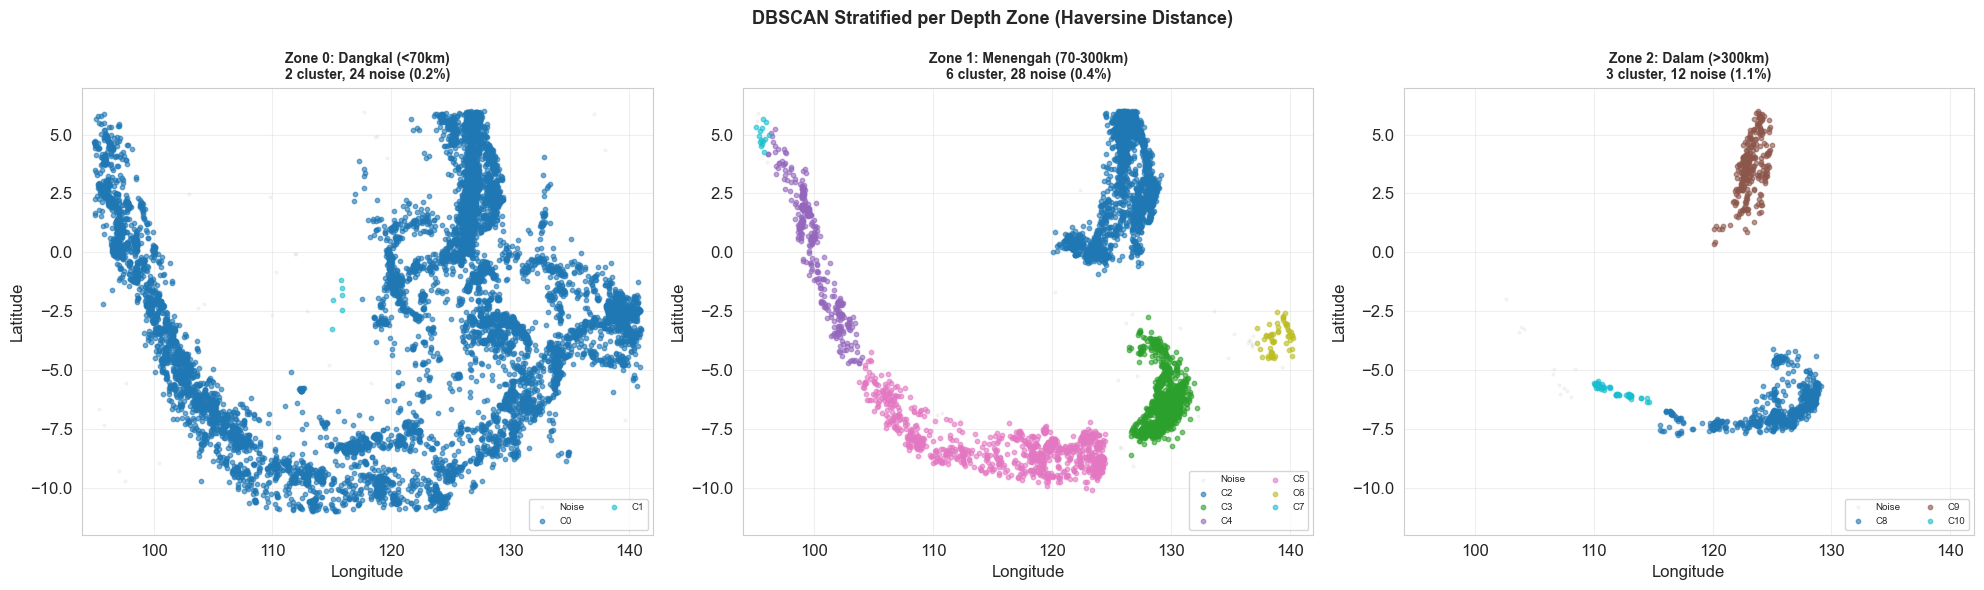

In [24]:
# 6.3 Peta hasil DBSCAN (stratified per depth zone)
unique_labels = sorted(df_clean['cluster_dbscan'].unique())
n_labels = len(unique_labels)
cmap_db  = plt.cm.tab20(np.linspace(0, 1, max(n_labels, 1)))

# Warna khusus per depth zone untuk membedakan zona kedalaman
depth_colors = {0: 'Yellows', 1: 'Blues', 2: 'Reds'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
zone_names = {0: 'Dangkal (<70km)', 1: 'Menengah (70-300km)', 2: 'Dalam (>300km)'}

for zone, ax in enumerate(axes):
    df_zone = df_clean[df_clean['depth_cat'] == zone]
    noise   = df_zone[df_zone['cluster_dbscan'] == -1]
    non_noise = df_zone[df_zone['cluster_dbscan'] != -1]
    zone_labels = sorted(non_noise['cluster_dbscan'].unique())
    n_zl = len(zone_labels)
    cmap_z = plt.cm.tab10(np.linspace(0, 1, max(n_zl, 1)))

    ax.scatter(noise['longitude'], noise['latitude'],
               s=4, alpha=0.2, color='lightgray', label='Noise')
    for j, lbl in enumerate(zone_labels):
        s = non_noise[non_noise['cluster_dbscan'] == lbl]
        ax.scatter(s['longitude'], s['latitude'],
                   s=10, alpha=0.6, color=cmap_z[j % len(cmap_z)], label=f'C{lbl}')

    ax.set_title(f'Zone {zone}: {zone_names[zone]}\n'
                 f'{n_zl} cluster, {len(noise)} noise ({len(noise)/max(len(df_zone),1)*100:.1f}%)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_xlim(94, 142); ax.set_ylim(-12, 7)
    ax.legend(loc='lower right', fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('DBSCAN Stratified per Depth Zone (Haversine Distance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

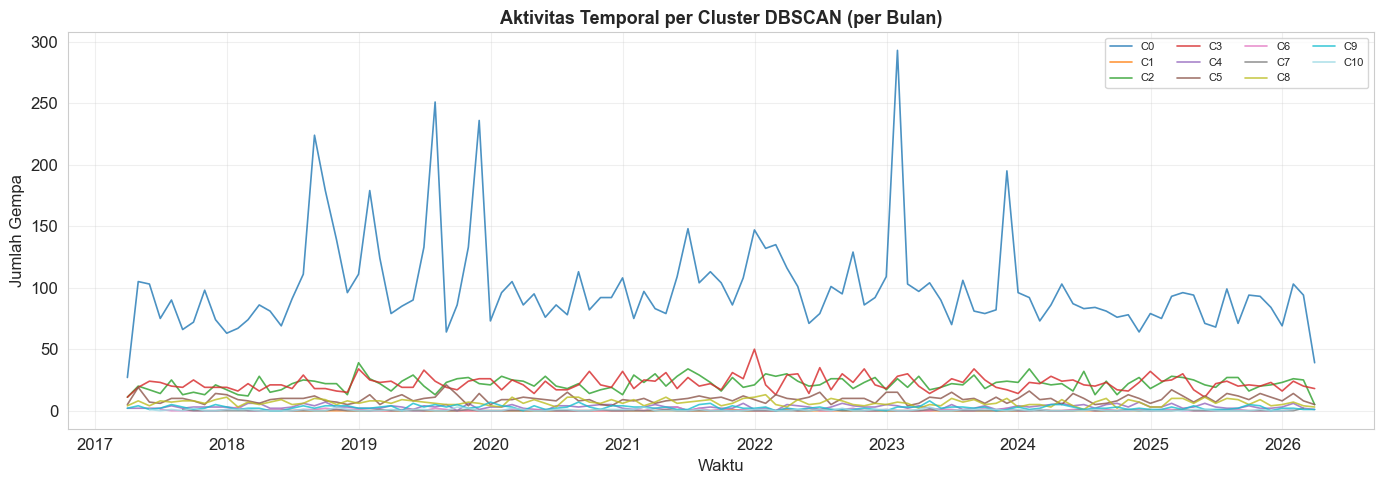

In [25]:
# 6.4 Distribusi temporal per cluster DBSCAN
fig, ax = plt.subplots(figsize=(14, 5))
non_noise_labels = [l for l in sorted(df_clean['cluster_dbscan'].unique()) if l != -1]
cmap_t = plt.cm.tab20(np.linspace(0, 1, max(len(non_noise_labels), 1)))
for i, lbl in enumerate(non_noise_labels):
    s = df_clean[df_clean['cluster_dbscan'] == lbl]
    s_monthly = s.resample('ME', on='time').size()
    ax.plot(s_monthly.index, s_monthly.values, label=f'C{lbl}',
            linewidth=1.2, alpha=0.8, color=cmap_t[i % len(cmap_t)])
ax.set_title('Aktivitas Temporal per Cluster DBSCAN (per Bulan)', fontsize=13, fontweight='bold')
ax.set_xlabel('Waktu'); ax.set_ylabel('Jumlah Gempa')
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Evaluasi & Perbandingan Algoritma

In [26]:
eval_summary = pd.DataFrame({
    'Algoritma'           : ['K-Means', 'DBSCAN'],
    'Jumlah Cluster'      : [best_k, n_clust_db],
    'Silhouette Score'    : [round(sil_km, 4), round(sil_db, 4)],
    'Davies-Bouldin Index': [round(db_km, 4), round(dbi_db, 4)],
    'Noise Points'        : [0, n_noise_db],
    'Fitur Waktu'         : ['Ya', 'Ya']
})
print('=== Perbandingan Evaluasi Algoritma Clustering (dengan Fitur Waktu) ===')
print(eval_summary.to_string(index=False))

=== Perbandingan Evaluasi Algoritma Clustering (dengan Fitur Waktu) ===
Algoritma  Jumlah Cluster  Silhouette Score  Davies-Bouldin Index  Noise Points Fitur Waktu
  K-Means               7            0.3739                0.9403             0          Ya
   DBSCAN              11           -0.3262                1.5782            64          Ya


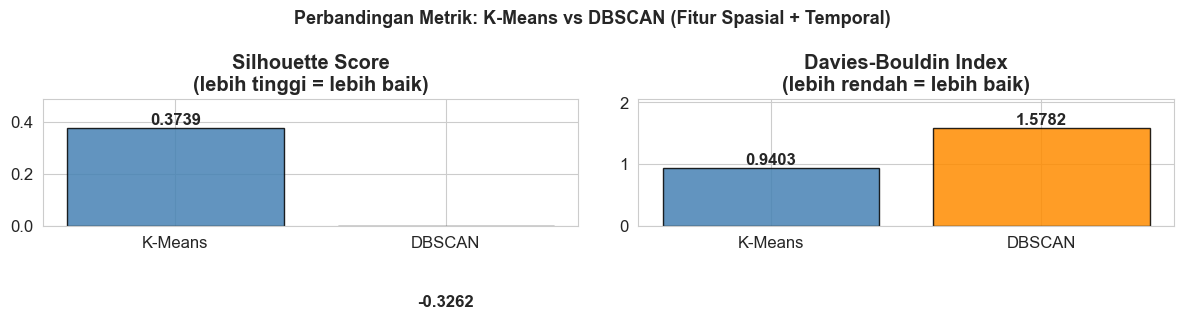

In [27]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
algos = ['K-Means', 'DBSCAN']

bars = axes[0].bar(algos, [sil_km, sil_db],
                   color=['steelblue', 'darkorange'], alpha=0.85, edgecolor='black')
axes[0].set_title('Silhouette Score\n(lebih tinggi = lebih baik)', fontweight='bold')
axes[0].set_ylim(0, max(sil_km, sil_db) * 1.3)
for bar, v in zip(bars, [sil_km, sil_db]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1].bar(algos, [db_km, dbi_db],
                    color=['steelblue', 'darkorange'], alpha=0.85, edgecolor='black')
axes[1].set_title('Davies-Bouldin Index\n(lebih rendah = lebih baik)', fontweight='bold')
axes[1].set_ylim(0, max(db_km, dbi_db) * 1.3)
for bar, v in zip(bars2, [db_km, dbi_db]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Perbandingan Metrik: K-Means vs DBSCAN (Fitur Spasial + Temporal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

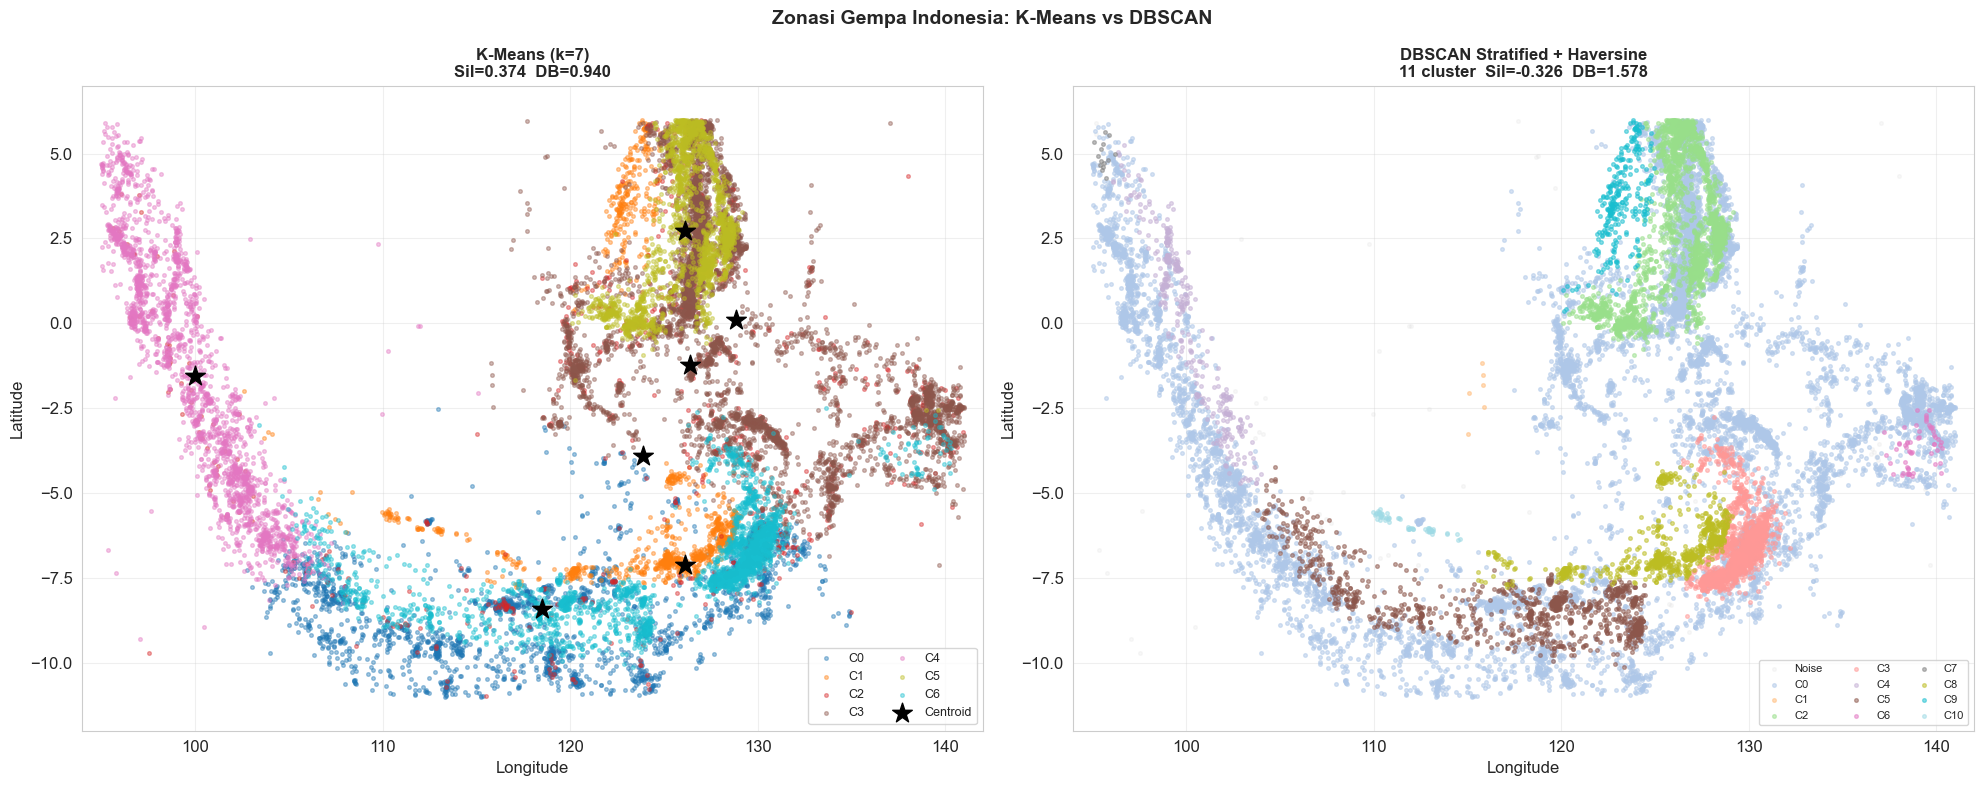

In [28]:
# Side-by-side peta perbandingan
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# K-Means
ax1 = axes[0]
for c in range(best_k):
    s = df_clean[df_clean['cluster_kmeans'] == c]
    ax1.scatter(s['longitude'], s['latitude'], s=7, alpha=0.4,
                color=colors_km[c], label=f'C{c}')
ax1.scatter(centers_orig[:, 1], centers_orig[:, 0], c='black', s=220,
            marker='*', zorder=5, label='Centroid')
ax1.set_title(f'K-Means (k={best_k})\nSil={sil_km:.3f}  DB={db_km:.3f}',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude'); ax1.set_ylabel('Latitude')
ax1.set_xlim(94, 142); ax1.set_ylim(-12, 7)
ax1.legend(loc='lower right', fontsize=9, ncol=2); ax1.grid(True, alpha=0.3)

# DBSCAN gabungan semua zone
ax2 = axes[1]
all_db_labels = sorted(df_clean['cluster_dbscan'].unique())
cmap_all = plt.cm.tab20(np.linspace(0, 1, max(len(all_db_labels), 1)))
for i, lbl in enumerate(all_db_labels):
    s = df_clean[df_clean['cluster_dbscan'] == lbl]
    c = 'lightgray' if lbl == -1 else cmap_all[i % len(cmap_all)]
    a = 0.15 if lbl == -1 else 0.5
    ax2.scatter(s['longitude'], s['latitude'], s=7, alpha=a, color=c,
                label='Noise' if lbl == -1 else f'C{lbl}')
ax2.set_title(f'DBSCAN Stratified + Haversine\n'
              f'{n_clust_db} cluster  Sil={sil_db:.3f}  DB={dbi_db:.3f}',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude'); ax2.set_ylabel('Latitude')
ax2.set_xlim(94, 142); ax2.set_ylim(-12, 7)
ax2.legend(loc='lower right', fontsize=8, ncol=3); ax2.grid(True, alpha=0.3)

plt.suptitle('Zonasi Gempa Indonesia: K-Means vs DBSCAN',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

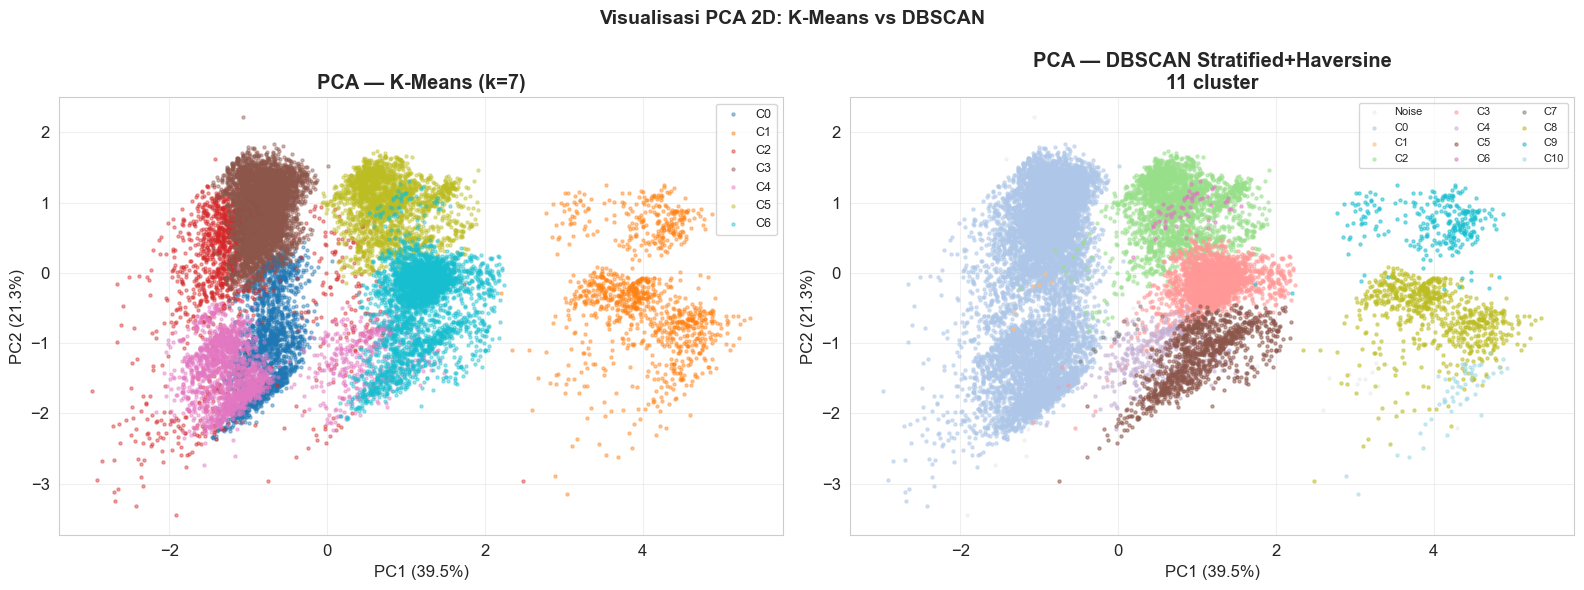

Variansi yang dijelaskan 2 PC: 60.77%


In [29]:
# PCA 2D visualization
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(best_k):
    m = df_clean['cluster_kmeans'].values == c
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1], s=5, alpha=0.4,
                    color=colors_km[c], label=f'C{c}')
axes[0].set_title(f'PCA — K-Means (k={best_k})', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

all_db_labels_pca = sorted(df_clean['cluster_dbscan'].unique())
cmap_pca = plt.cm.tab20(np.linspace(0, 1, max(len(all_db_labels_pca), 1)))
for i, lbl in enumerate(all_db_labels_pca):
    m = df_clean['cluster_dbscan'].values == lbl
    c = 'lightgray' if lbl == -1 else cmap_pca[i % len(cmap_pca)]
    a = 0.2 if lbl == -1 else 0.5
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], s=5, alpha=a, color=c,
                    label='Noise' if lbl == -1 else f'C{lbl}')
axes[1].set_title(f'PCA — DBSCAN Stratified+Haversine\n{n_clust_db} cluster', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8, ncol=3); axes[1].grid(True, alpha=0.3)

plt.suptitle('Visualisasi PCA 2D: K-Means vs DBSCAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Variansi yang dijelaskan 2 PC: {sum(pca.explained_variance_ratio_)*100:.2f}%')

---
## 8. Diskusi & Kesimpulan

In [30]:
print('=' * 65)
print('    RINGKASAN HASIL CLUSTERING ZONA GEMPA INDONESIA')
print('=' * 65)
print(f'  Total data yang diproses : {len(df_clean):,} gempa')
print(f'  Fitur                    : {all_features}')
print()
print('  --- K-Means ---')
print(f'    k optimal              : {best_k}')
print(f'    Silhouette Score       : {sil_km:.4f}')
print(f'    Davies-Bouldin Index   : {db_km:.4f}')
print()
print('  --- DBSCAN (Stratified + Haversine) ---')
print(f'    Jumlah cluster total   : {n_clust_db}')
print(f'    Noise points           : {n_noise_db} ({n_noise_db/len(df_clean)*100:.2f}%)')
print(f'    Silhouette Score       : {sil_db:.4f}')
print(f'    Davies-Bouldin Index   : {dbi_db:.4f}')
print()
winner = 'K-Means' if sil_km >= sil_db else 'DBSCAN'
print(f'  --- Algoritma Terbaik: {winner} ---')
print('=' * 65)

    RINGKASAN HASIL CLUSTERING ZONA GEMPA INDONESIA
  Total data yang diproses : 18,289 gempa
  Fitur                    : ['latitude', 'longitude', 'depth', 'mag', 'depth_cat']

  --- K-Means ---
    k optimal              : 7
    Silhouette Score       : 0.3739
    Davies-Bouldin Index   : 0.9403

  --- DBSCAN (Stratified + Haversine) ---
    Jumlah cluster total   : 11
    Noise points           : 64 (0.35%)
    Silhouette Score       : -0.3262
    Davies-Bouldin Index   : 1.5782

  --- Algoritma Terbaik: K-Means ---


### Kesimpulan

1. **Pendekatan Fitur Waktu (Post-hoc):** Sesuai saran bahwa satu titik koordinat dapat mengalami gempa berkali-kali di waktu berbeda, analisis temporal dilakukan secara *post-hoc* — cluster dibentuk berdasarkan karakteristik spasial-seismik, kemudian pola waktu dianalisis di dalam setiap cluster. Pendekatan ini dipilih karena memasukkan waktu langsung sebagai fitur clustering terbukti mendistorsi zonasi: cluster terbentuk berdasarkan periode waktu, bukan zona geografis.

2. **Fitur `depth_cat`:** Penambahan kategori kedalaman (dangkal/menengah/dalam) sebagai domain knowledge geologis meningkatkan Silhouette Score K-Means dari 0.25 menjadi **0.37** dan menurunkan Davies-Bouldin dari 1.3 menjadi **0.94**.

3. **K-Means (k=7):** Menghasilkan 7 zona yang merepresentasikan kombinasi wilayah geografis dan lapisan kedalaman. Lebih cocok untuk tujuan zonasi risiko keseluruhan Indonesia.

4. **DBSCAN (Stratified + Haversine):** Dijalankan terpisah per lapisan kedalaman dengan jarak Haversine. Hasil terbaik pada zona menengah (Sil=0.65) dan dalam (Sil=0.70). Lebih tepat digunakan sebagai analisis densitas per lapisan, bukan zonasi tunggal.

5. **Implikasi Mitigasi:** Analisis temporal post-hoc menunjukkan cluster mana yang aktif secara konsisten vs. sporadis — informasi ini dapat digunakan untuk menentukan prioritas kesiapsiagaan bencana berdasarkan zona dan periode aktivitas seismik.

---
*Sumber data: USGS Earthquake Catalog — earthquake.usgs.gov*